<a href="https://colab.research.google.com/github/Arianna400/computer_vision_part1/blob/main/HoughTransform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Hough Transform

In [12]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [13]:
!wget https://raw.github.com/Arianna400/computer_vision_part1/main/work1.jpg

--2026-05-26 17:57:28--  https://raw.github.com/Arianna400/computer_vision_part1/main/work1.jpg
Resolving raw.github.com (raw.github.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.github.com (raw.github.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/Arianna400/computer_vision_part1/main/work1.jpg [following]
--2026-05-26 17:57:28--  https://raw.githubusercontent.com/Arianna400/computer_vision_part1/main/work1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94758 (93K) [image/jpeg]
Saving to: ‘work1.jpg.2’

work1.jpg.2         100%[===================>]  92.54K  --.-KB/s    in 0.03s   

2026-05-26 17:57:28 (2.59 MB/s) - ‘wor

(<Axes: >, <matplotlib.image.AxesImage at 0x7835d42deea0>)

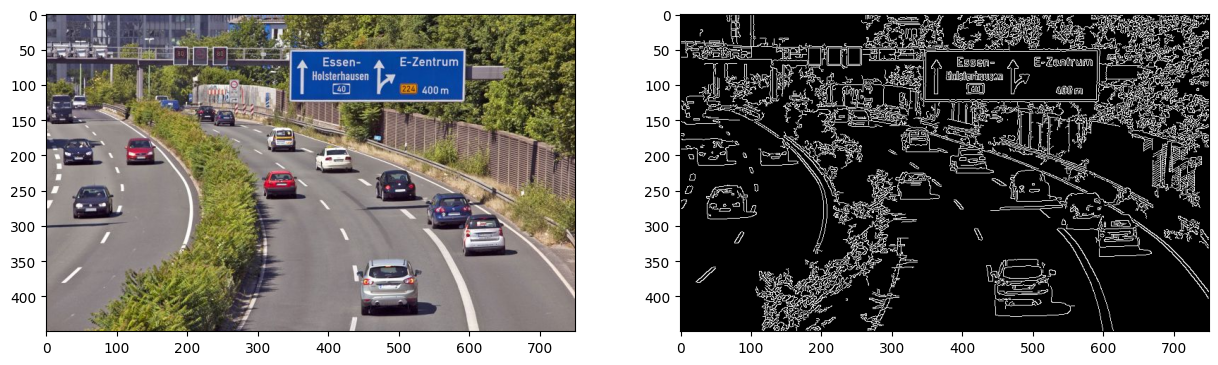

In [14]:
img = cv2.imread('work1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, threshold1=100, threshold2=550)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(edges, cmap='gray')

(<Axes: >, <matplotlib.image.AxesImage at 0x7835d32078f0>)

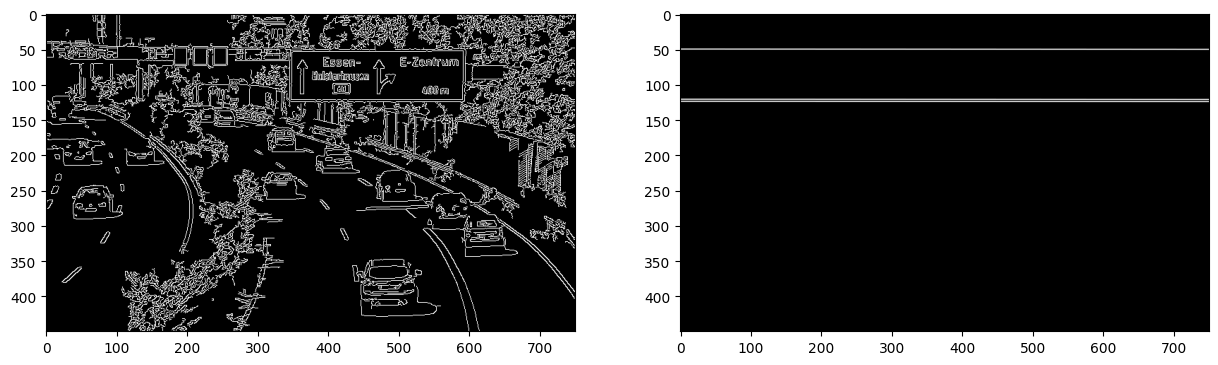

In [15]:
lines = cv2.HoughLines(edges, rho=1, theta=2*np.pi/180, threshold=50)
hough = np.zeros_like(edges)

for i in range(0, len(lines[0:3])):
    rho = lines[i][0][0]
    theta = lines[i][0][1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    cv2.line(hough, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray')
plt.subplot(122), plt.imshow(hough, cmap='gray')